In [1]:
import sys
sys.path.append('..')
from pandas import Series
import pandas as pd
import numpy as np
import re
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from pandas import DataFrame, read_excel
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from Library.dslabs_functions import CLASS_EVAL_METRICS, read_train_test_from_df
from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsClassifier

In [2]:
filename = "../DataBase/DataCollection.xlsx"
sheet = "895 Records"
random_state = 2026
eval_metric = "Recall"

dataset: DataFrame = read_excel(filename, sheet_name=sheet)
target = "Dissolution"

print(dataset.shape)

(895, 40)


`Encoding`

In [3]:
dissolve_encoding: dict[str, int] = {"NO": 0,"YES": 1}
sample_type_enconding: dict[str, int] = {"pellet": 0, "waste": 1, "fiber": 2, "film": 3, "powder": 4}

encoding: dict[str, dict[str, int]] = {
    "Dissolution": dissolve_encoding,
    "Sample type": sample_type_enconding
}
df: DataFrame = dataset.replace(encoding, inplace=False)
df = df.drop(columns=["Polymer_ID", "Solvent_ID", "Polymer", "Solvent"])


`Feature BoxPlot before Scaling`

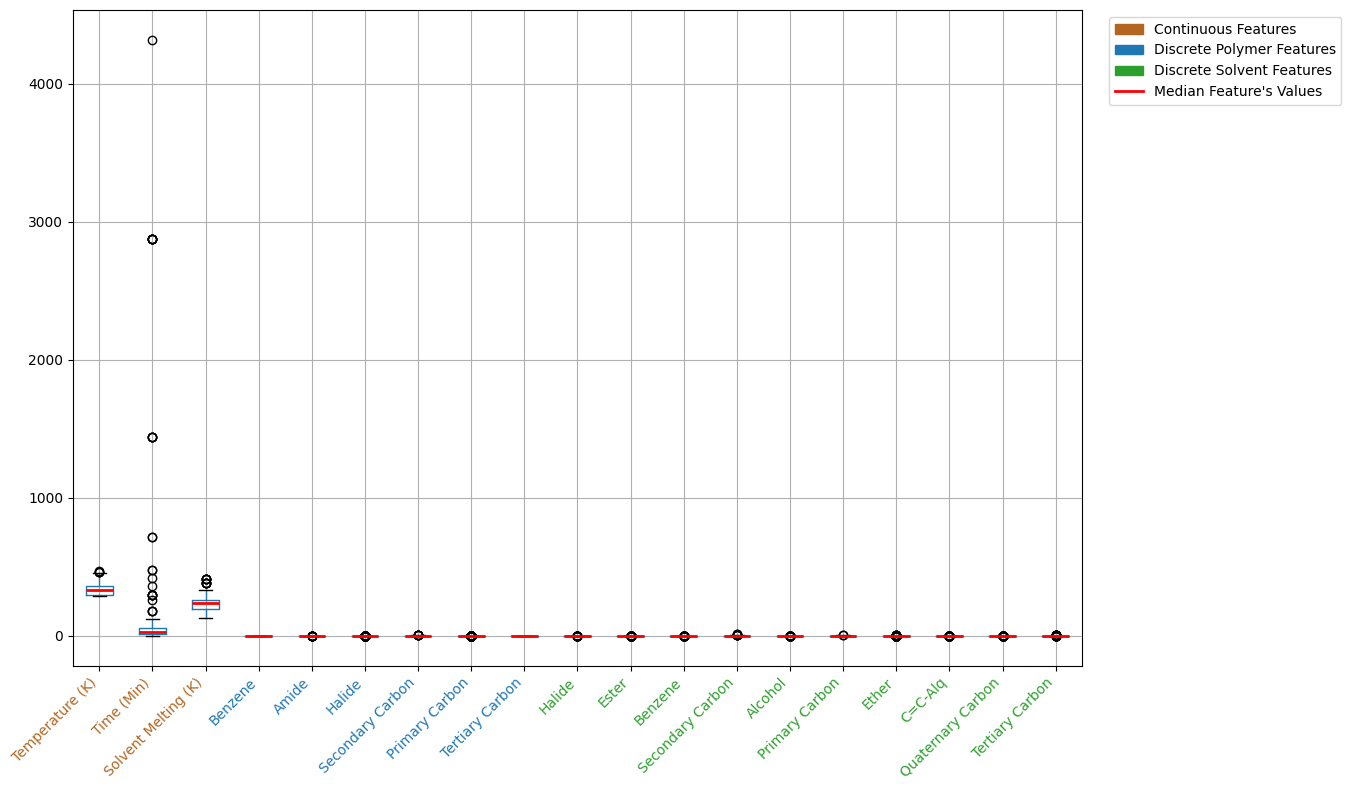

In [4]:
numeric_cols = dataset.select_dtypes(include=['number'])

def is_binary(series):
    return set(series.dropna().unique()).issubset({0, 1})

binary_cols    = [col for col in numeric_cols.columns if is_binary(numeric_cols[col])]
nonbinary_cols = [col for col in numeric_cols.columns if col not in binary_cols]

key_cols      = ['Temperature (K)', 'Time (min)', 'Solvent melting (K)']
remove_cols   = ['Polymer_ID', 'Solvent_ID', 'Dissolution', 'Polymer_ester', 'Polymer_urethane']
selected_cols = key_cols + [col for col in nonbinary_cols if col not in key_cols]
selected_cols = [col for col in selected_cols if col not in remove_cols]

polymer_discrete = [col for col in selected_cols if col.startswith('Polymer_')]
solvent_discrete = [col for col in selected_cols if col.startswith('Solvent_')]

if "Sample Type" in selected_cols and "Sample Type" not in polymer_discrete:
    polymer_discrete.append("Sample Type")

selected_cols = (
    key_cols
    + polymer_discrete
    + [col for col in selected_cols if col not in key_cols + polymer_discrete + solvent_discrete]
    + solvent_discrete
)

def clean_carbon_tokens(s):
    placeholder = "__CCALQ__"
    s = s.replace("C=C-alq", placeholder)
    for pattern, repl in [(r'CH3\b', 'Primary Carbon'), (r'CH2\b', 'Secondary Carbon'),
                          (r'CH\b', 'Tertiary Carbon'), (r'\bC\b', 'Quaternary Carbon')]:
        s = re.sub(pattern, repl, s)
    return s.replace(placeholder, "C=C-alq")

def rename_label(col):
    base = col[len('Polymer_'):] if col.startswith('Polymer_') else col[len('Solvent_'):] if col.startswith('Solvent_') else col
    return clean_carbon_tokens(base).replace('_', ' ').title()

renamed_labels = [rename_label(col) for col in selected_cols]

KEY_COLOR  = "#b4651f"
POLY_COLOR = "#1f77b4"
SOLV_COLOR = "#2ca02c"

plt.style.use('default')
plt.figure(figsize=(16, 8))
dataset[selected_cols].boxplot(medianprops=dict(color='red', linewidth=2))

ax = plt.gca()
ax.set_xticks(range(1, len(selected_cols) + 1))
ax.set_xticklabels(renamed_labels, rotation=45, ha='right')

for i, col in enumerate(selected_cols):
    if col in key_cols:           color = KEY_COLOR
    elif col in polymer_discrete: color = POLY_COLOR
    elif col in solvent_discrete: color = SOLV_COLOR
    else:                         color = POLY_COLOR
    ax.xaxis.get_major_ticks()[i].label1.set_color(color)

legend_patches = [
    mpatches.Patch(color=KEY_COLOR,  label='Continuous Features'),
    mpatches.Patch(color=POLY_COLOR, label='Discrete Polymer Features'),
    mpatches.Patch(color=SOLV_COLOR, label='Discrete Solvent Features'),
    Line2D([0], [0], color='red', lw=2, label="Median Feature's Values"),
]

plt.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

`No Scaling`

In [5]:
X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

X_train, X_test, y_train , y_test = train_test_split(df.drop(columns=["Dissolution"]), df["Dissolution"], test_size=0.3,random_state=random_state,stratify=df["Dissolution"])  

df_train_NoScaling = DataFrame(X_train, columns=X.columns)
df_train_NoScaling["Dissolution"] = y_train

df_test_NoScaling = DataFrame(X_test, columns=X.columns)
df_test_NoScaling["Dissolution"] = y_test.values

trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(df_train_NoScaling, df_test_NoScaling, target)

`NB`

In [6]:
clf = MultinomialNB()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)
recall_NB_NoScaling = CLASS_EVAL_METRICS["Recall"](tstY, prdY)
print("Recall Default NB:", recall_NB_NoScaling)

Recall Default NB: 0.782608695652174


`KNN`

In [7]:
clf = KNeighborsClassifier()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)

recall_KNN_NoScaling = CLASS_EVAL_METRICS["Recall"](tstY, prdY)

print("Recall Default KNN:", recall_KNN_NoScaling)

Recall Default KNN: 0.4608695652173913


`MinMax Continuous Features`

In [8]:
X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

continuous_vars = ["Time (min)", "Temperature (K)", "Solvent melting (K)"]

X_train, X_test, y_train , y_test = train_test_split(df.drop(columns=["Dissolution"]), df["Dissolution"], test_size=0.3,random_state=random_state,stratify=df["Dissolution"])  

scaler = MinMaxScaler()
scaler.fit(X[continuous_vars])

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_vars] = scaler.transform(X_train[continuous_vars])
X_test_scaled[continuous_vars]  = scaler.transform(X_test[continuous_vars])

df_train_MinMaxScalerContinuous = DataFrame(X_train_scaled, columns=X.columns)
df_train_MinMaxScalerContinuous["Dissolution"] = y_train.values

df_test_MinMaxScalerContinuous = DataFrame(X_test_scaled, columns=X.columns)
df_test_MinMaxScalerContinuous["Dissolution"] = y_test.values


trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(df_train_MinMaxScalerContinuous, df_test_MinMaxScalerContinuous, target)


`NB`

In [9]:
clf = MultinomialNB()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)
recall_NB_MinMaxContinuous = CLASS_EVAL_METRICS["Recall"](tstY, prdY)
print("Recall Default NB:", recall_NB_MinMaxContinuous)

Recall Default NB: 0.6434782608695652


`KNN`

In [10]:
clf = KNeighborsClassifier()

clf.fit(trnX, trnY)
prdY = clf.predict(tstX)

recall_KNN_MinMaxContinuous = CLASS_EVAL_METRICS["Recall"](tstY, prdY)

print("Recall Default KNN:", recall_KNN_MinMaxContinuous)

Recall Default KNN: 0.8695652173913043


`MinMax All Features`

In [11]:
X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

X_train, X_test, y_train , y_test = train_test_split(df.drop(columns=["Dissolution"]), df["Dissolution"], test_size=0.3,random_state=random_state,stratify=df["Dissolution"])  

scaler = MinMaxScaler()
scaler.fit(X) 

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

df_train_MinMaxScaler = DataFrame(X_train_scaled, columns=X.columns)
df_train_MinMaxScaler["Dissolution"] = y_train.values

df_test_MinMaxScaler = DataFrame(X_test_scaled, columns=X.columns)
df_test_MinMaxScaler["Dissolution"] = y_test.values

trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(df_train_MinMaxScaler, df_test_MinMaxScaler, target)

`NB`

In [12]:
clf = MultinomialNB()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)
recall_NB_MinMax = CLASS_EVAL_METRICS["Recall"](tstY, prdY)
print("Recall Default NB:", recall_NB_MinMax)

Recall Default NB: 0.6608695652173913


`KNN`

In [13]:
clf = KNeighborsClassifier()

clf.fit(trnX, trnY)
prdY = clf.predict(tstX)

recall_KNN_MinMax= CLASS_EVAL_METRICS["Recall"](tstY, prdY)

print("Recall Default KNN:", recall_KNN_MinMax)

Recall Default KNN: 0.8608695652173913


`LogMinMax Continuous Features`

In [14]:
X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

continuous_vars = ["Time (min)", "Temperature (K)", "Solvent melting (K)"]

X_train, X_test, y_train , y_test = train_test_split(df.drop(columns=["Dissolution"]), df["Dissolution"], test_size=0.3,random_state=random_state,stratify=df["Dissolution"])  

X_log_full = np.log1p(X[continuous_vars]) 
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
min_max_scaler.fit(X_log_full)

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[continuous_vars] = min_max_scaler.transform(np.log1p(X_train[continuous_vars]))
X_test_scaled[continuous_vars]  = min_max_scaler.transform(np.log1p(X_test[continuous_vars]))

df_train_LogMinMaxScalerContinuous = DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
df_train_LogMinMaxScalerContinuous["Dissolution"] = y_train.values

df_test_LogMinMaxScalerContinuous = DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
df_test_LogMinMaxScalerContinuous["Dissolution"] = y_test.values

trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(df_train_LogMinMaxScalerContinuous, df_test_LogMinMaxScalerContinuous, target)

`NB`

In [15]:
clf = MultinomialNB()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)
recall_NB_LogMinMaxContinuous = CLASS_EVAL_METRICS["Recall"](tstY, prdY)
print("Recall Default NB:", recall_NB_LogMinMaxContinuous)

Recall Default NB: 0.6434782608695652


`KNN`

In [16]:
clf = KNeighborsClassifier()

clf.fit(trnX, trnY)
prdY = clf.predict(tstX)

recall_KNN_LogMinMaxContinuous = CLASS_EVAL_METRICS["Recall"](tstY, prdY)

print("Recall Default KNN:", recall_KNN_LogMinMaxContinuous)

Recall Default KNN: 0.8695652173913043


`Log+MinMax All Features`

In [17]:
X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]

X_train, X_test, y_train , y_test = train_test_split(df.drop(columns=["Dissolution"]), df["Dissolution"], test_size=0.3,random_state=random_state,stratify=df["Dissolution"])  

X_log_full = np.log1p(X)                  
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
min_max_scaler.fit(X_log_full)  

X_train_scaled = min_max_scaler.transform(np.log1p(X_train))
X_test_scaled  = min_max_scaler.transform(np.log1p(X_test))

df_train_LogMinMaxScaler = DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
df_train_LogMinMaxScaler["Dissolution"] = y_train.values

df_test_LogMinMaxScaler = DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)
df_test_LogMinMaxScaler["Dissolution"] = y_test.values

trnX, tstX, trnY, tstY, labels, vars = read_train_test_from_df(df_train_LogMinMaxScaler, df_test_LogMinMaxScaler, target)

`NB`

In [18]:
clf = MultinomialNB()
clf.fit(trnX, trnY)
prdY = clf.predict(tstX)
recall_NB_LogMinMax= CLASS_EVAL_METRICS["Recall"](tstY, prdY)
print("Recall Default NB:", recall_NB_LogMinMax)

Recall Default NB: 0.6608695652173913


`KNN`

In [19]:
clf = KNeighborsClassifier()

clf.fit(trnX, trnY)
prdY = clf.predict(tstX)

recall_KNN_LogMinMax = CLASS_EVAL_METRICS["Recall"](tstY, prdY)

print("Recall Default KNN:", recall_KNN_LogMinMax)

Recall Default KNN: 0.8869565217391304


`Comparison Performance Scaling Approaches`

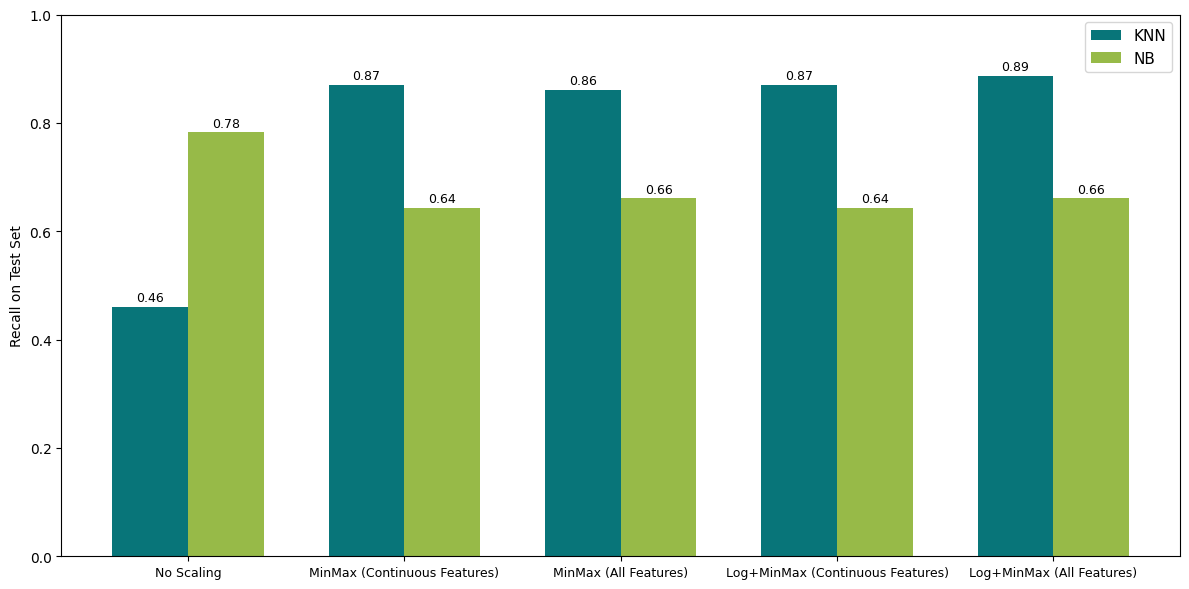

In [20]:
knn_values = [recall_KNN_NoScaling, recall_KNN_MinMaxContinuous, recall_KNN_MinMax, recall_KNN_LogMinMaxContinuous, recall_KNN_LogMinMax]
nb_values  = [recall_NB_NoScaling,  recall_NB_MinMaxContinuous,  recall_NB_MinMax,  recall_NB_LogMinMaxContinuous,  recall_NB_LogMinMax]

labels = [
    'No Scaling',
    'MinMax (Continuous Features)',
    'MinMax (All Features)',
    'Log+MinMax (Continuous Features)',
    'Log+MinMax (All Features)'
]

plt.style.use('default')
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars_knn = ax.bar(x - width/2, knn_values, width, label='KNN', color='#087579')
bars_nb  = ax.bar(x + width/2, nb_values,  width, label='NB',  color='#97BA48')

for bar in bars_knn:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

for bar in bars_nb:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Recall on Test Set')
ax.set_ylim(0, 1.0)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

### Feature BoxPlot after LogMinMax Scaling

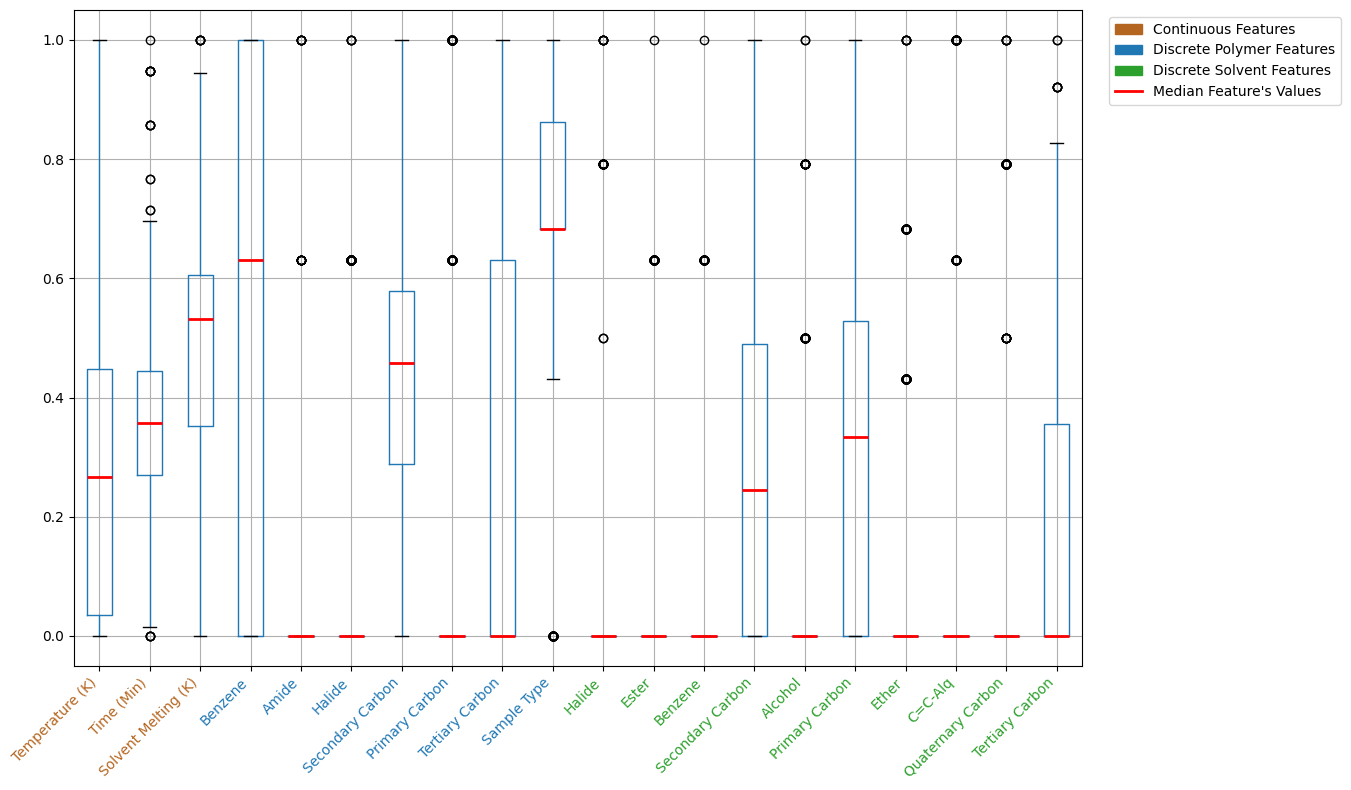

In [21]:
dataset_logMinMax = pd.concat([df_train_LogMinMaxScaler, df_test_LogMinMaxScaler]).sort_index()
numeric_cols = dataset_logMinMax.select_dtypes(include=['number'])

def is_binary(series):
    return set(series.dropna().unique()).issubset({0, 1})

binary_cols    = [col for col in numeric_cols.columns if is_binary(numeric_cols[col])]
nonbinary_cols = [col for col in numeric_cols.columns if col not in binary_cols]

key_cols      = ['Temperature (K)', 'Time (min)', 'Solvent melting (K)']
remove_cols   = ['Polymer_ID', 'Solvent_ID', 'Dissolution', 'Polymer_ester', 'Polymer_urethane']
selected_cols = key_cols + [col for col in nonbinary_cols if col not in key_cols]
selected_cols = [col for col in selected_cols if col not in remove_cols]

polymer_discrete = [col for col in selected_cols if col.startswith('Polymer_')]
solvent_discrete = [col for col in selected_cols if col.startswith('Solvent_')]

if "Sample Type" in selected_cols and "Sample Type" not in polymer_discrete:
    polymer_discrete.append("Sample Type")

selected_cols = (
    key_cols
    + polymer_discrete
    + [col for col in selected_cols if col not in key_cols + polymer_discrete + solvent_discrete]
    + solvent_discrete
)

def clean_carbon_tokens(s):
    placeholder = "__CCALQ__"
    s = s.replace("C=C-alq", placeholder)
    for pattern, repl in [(r'CH3\b', 'Primary Carbon'), (r'CH2\b', 'Secondary Carbon'),
                          (r'CH\b', 'Tertiary Carbon'), (r'\bC\b', 'Quaternary Carbon')]:
        s = re.sub(pattern, repl, s)
    return s.replace(placeholder, "C=C-alq")

def rename_label(col):
    base = col[len('Polymer_'):] if col.startswith('Polymer_') else col[len('Solvent_'):] if col.startswith('Solvent_') else col
    return clean_carbon_tokens(base).replace('_', ' ').title()

renamed_labels = [rename_label(col) for col in selected_cols]

KEY_COLOR  = "#b4651f"
POLY_COLOR = "#1f77b4"
SOLV_COLOR = "#2ca02c"

plt.style.use('default')
plt.figure(figsize=(16, 8))
dataset_logMinMax[selected_cols].boxplot(medianprops=dict(color='red', linewidth=2))

ax = plt.gca()
ax.set_xticks(range(1, len(selected_cols) + 1))
ax.set_xticklabels(renamed_labels, rotation=45, ha='right')

for i, col in enumerate(selected_cols):
    if col in key_cols:           color = KEY_COLOR
    elif col in polymer_discrete: color = POLY_COLOR
    elif col in solvent_discrete: color = SOLV_COLOR
    else:                         color = POLY_COLOR
    ax.xaxis.get_major_ticks()[i].label1.set_color(color)

legend_patches = [
    mpatches.Patch(color=KEY_COLOR,  label='Continuous Features'),
    mpatches.Patch(color=POLY_COLOR, label='Discrete Polymer Features'),
    mpatches.Patch(color=SOLV_COLOR, label='Discrete Solvent Features'),
    Line2D([0], [0], color='red', lw=2, label="Median Feature's Values"),
]

plt.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.02, 1), frameon=True)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

`Balacing Approaches`

`Original Train Data Records Count`

In [22]:
target_count: Series = df_train_LogMinMaxScaler[target].value_counts()
positive_class = target_count.idxmin()
negative_class = target_count.idxmax()

df_positives: Series = df_train_LogMinMaxScaler[df_train_LogMinMaxScaler[target] == positive_class]
df_negatives: Series = df_train_LogMinMaxScaler[df_train_LogMinMaxScaler[target] == negative_class]

In [23]:
orig_neg  = df_train_LogMinMaxScaler["Dissolution"].value_counts()[0] 
orig_pos  = df_train_LogMinMaxScaler["Dissolution"].value_counts()[1] 
df_train_LogMinMaxScaler["Dissolution"].value_counts()

Dissolution
0    358
1    268
Name: count, dtype: int64

`UnderSampled Train Data Records Count`

In [24]:
df_neg_sample = df_negatives.sample(len(df_positives), random_state=random_state)
df_under = pd.concat([df_positives, df_neg_sample], axis=0).reset_index(drop=True)

In [25]:
under_neg  = df_under["Dissolution"].value_counts()[0] 
under_pos  = df_under["Dissolution"].value_counts()[1] 
df_under["Dissolution"].value_counts()

Dissolution
1    268
0    268
Name: count, dtype: int64

`OverSampled Train Data Records Count`

In [26]:
df_pos_sample = df_positives.sample(len(df_negatives), replace=True, random_state=random_state)
df_over = pd.concat([df_pos_sample, df_negatives], axis=0).reset_index(drop=True)

In [27]:
over_neg  = df_over["Dissolution"].value_counts()[0] 
over_pos  = df_over["Dissolution"].value_counts()[1] 
df_over["Dissolution"].value_counts()

Dissolution
1    358
0    358
Name: count, dtype: int64

`Balacing Approaches Comparison`

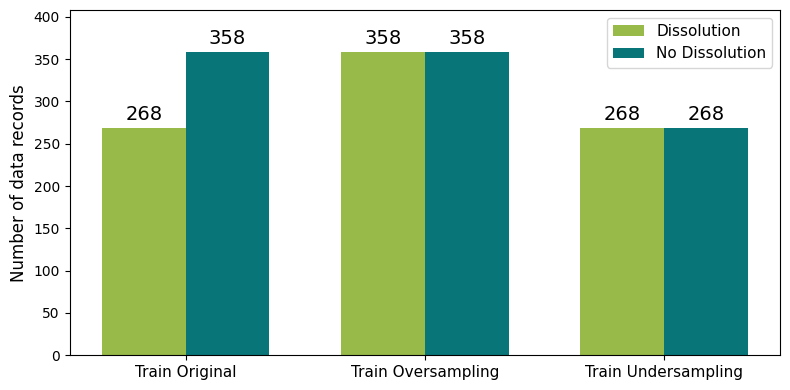

In [28]:
color_pos = '#97BA48'
color_neg = '#087579'

orig_counts  = [orig_pos,  orig_neg]
over_counts  = [over_pos,  over_neg]
under_counts = [under_pos, under_neg]

labels = ['Train Original', 'Train Oversampling', 'Train Undersampling']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 4))

bar1 = ax.bar(x - width/2, [orig_counts[0], over_counts[0], under_counts[0]], width, label='Dissolution',    color=color_pos)
bar2 = ax.bar(x + width/2, [orig_counts[1], over_counts[1], under_counts[1]], width, label='No Dissolution', color=color_neg)

for bars in [bar1, bar2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 5,
                f'{int(height)}', ha='center', va='bottom', fontsize=14)

y_max = max(max(orig_counts), max(over_counts), max(under_counts))
ax.set_ylim(0, y_max + 50)
ax.set_ylabel('Number of data records', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()